In [557]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

## Carga dataset

In [558]:
df_crimes = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed.csv")
df_crimes.head()

,Unnamed: 0,IUCR,Primary Type,Location Description,Arrest,Domestic,Beat,Ward,Community Area,FBI Code,...,Y Coordinate,Latitude,Longitude,Crime District,Nearest Police Station District,Nearest Police Station District Name,Distance Crime To Police Station,Season,Day,Day Time
0,0,1310,CRIMINAL DAMAGE,APARTMENT,False,False,332,5,43,14,...,1860189.0,41.771470,-87.605748,3,3,Grand Crossing,1367.540845,Winter,Tuesday,Night
1,1,1365,CRIMINAL TRESPASS,APARTMENT,True,True,223,3,38,26,...,1873623.0,41.808501,-87.630560,2,2,Wentworth,1380.313916,Winter,Tuesday,Night
2,2,0498,BATTERY,HOTEL / MOTEL,False,True,834,18,70,04B,...,1853048.0,41.752749,-87.708864,8,8,Chicago Lawn,3982.098345,Winter,Tuesday,Night
3,3,1320,CRIMINAL DAMAGE,STREET,False,False,321,20,42,14,...,1861188.0,41.774269,-87.605748,3,3,Grand Crossing,1005.009383,Winter,Tuesday,Night
4,4,0460,BATTERY,SIDEWALK,False,False,2531,29,25,08B,...,1907694.0,41.902858,-87.765574,25,25,Grand Central,1797.243049,Winter,Tuesday,Night


In [559]:
df_crimes.dtypes

Unnamed: 0                                int64
IUCR                                     object
Primary Type                             object
Location Description                     object
Arrest                                     bool
Domestic                                   bool
Beat                                      int64
Ward                                      int64
Community Area                            int64
FBI Code                                 object
X Coordinate                            float64
Y Coordinate                            float64
Latitude                                float64
Longitude                               float64
Crime District                            int64
Nearest Police Station District          object
Nearest Police Station District Name     object
Distance Crime To Police Station        float64
Season                                   object
Day                                      object
Day Time                                

In [560]:
df_crimes.describe()

,Unnamed: 0,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Distance Crime To Police Station
count,257514.000000,257514.000000,257514.000000,257514.000000,2.575140e+05,2.575140e+05,257514.000000,257514.000000,257514.000000,257514.000000
mean,129093.453140,1157.056339,23.185023,36.182437,1.165281e+06,1.887738e+06,41.847534,-87.668927,11.340712,1998.281721
std,74714.130029,709.339850,13.950074,21.606347,1.616071e+04,3.153780e+04,0.086723,0.051320,7.088088,1213.955887
min,0.000000,111.000000,1.000000,1.000000,1.092647e+06,1.813897e+06,41.644590,-87.768200,1.000000,12.262025
25%,64385.250000,533.000000,10.000000,22.000000,1.154005e+06,1.860559e+06,41.772692,-87.705488,5.000000,1219.384303
50%,128782.500000,1034.000000,23.000000,32.000000,1.167128e+06,1.894416e+06,41.866093,-87.656973,10.000000,1852.857265
75%,194028.750000,1732.000000,34.000000,53.000000,1.176638e+06,1.910460e+06,41.910074,-87.630560,17.000000,2509.772804
max,258611.000000,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,31.000000,14166.024970


## Eliminar duplicados

In [561]:
df_crimes = df_crimes.drop_duplicates()

## Rellenamos nulls de Location Description con nueva categoria UNKNOWN

In [562]:
df_crimes['Location Description'] = df_crimes['Location Description'].fillna('UNKNOWN')

## Dataset split

In [563]:
df, test_df = train_test_split(df_crimes, test_size=0.2, random_state=42, stratify=df_crimes['Arrest'])

print(df.shape, test_df.shape)

(206011, 21) (51503, 21)


In [564]:
df['Arrest'].value_counts()

Arrest
False    177616
True      28395
Name: count, dtype: int64

In [565]:
test_df['Arrest'].value_counts()

Arrest
False    44404
True      7099
Name: count, dtype: int64

## Tratamiento de outliers

In [566]:
# Transformación logarítmica de 'Distance Crime To Police Station' datos de entrenamiento
df_transformed = df.sort_index().copy()
df_transformed['Distance Crime To Police Station'] = np.log1p(df_transformed['Distance Crime To Police Station'])
df_transformed = df_transformed.sort_index()
df_transformed = df_transformed.reset_index(drop=True) 
df_transformed.describe()

# Transformación logarítmica de 'Distance Crime To Police Station' datos de test
test_df_transformed = test_df.sort_index().copy()
test_df_transformed['Distance Crime To Police Station'] = np.log1p(test_df_transformed['Distance Crime To Police Station'])
test_df_transformed = test_df_transformed.sort_index()
test_df_transformed = test_df_transformed.reset_index(drop=True)  

print("Train shape:", df_transformed.shape)
print("Test shape:", test_df_transformed.shape)

Train shape: (206011, 21)
Test shape: (51503, 21)


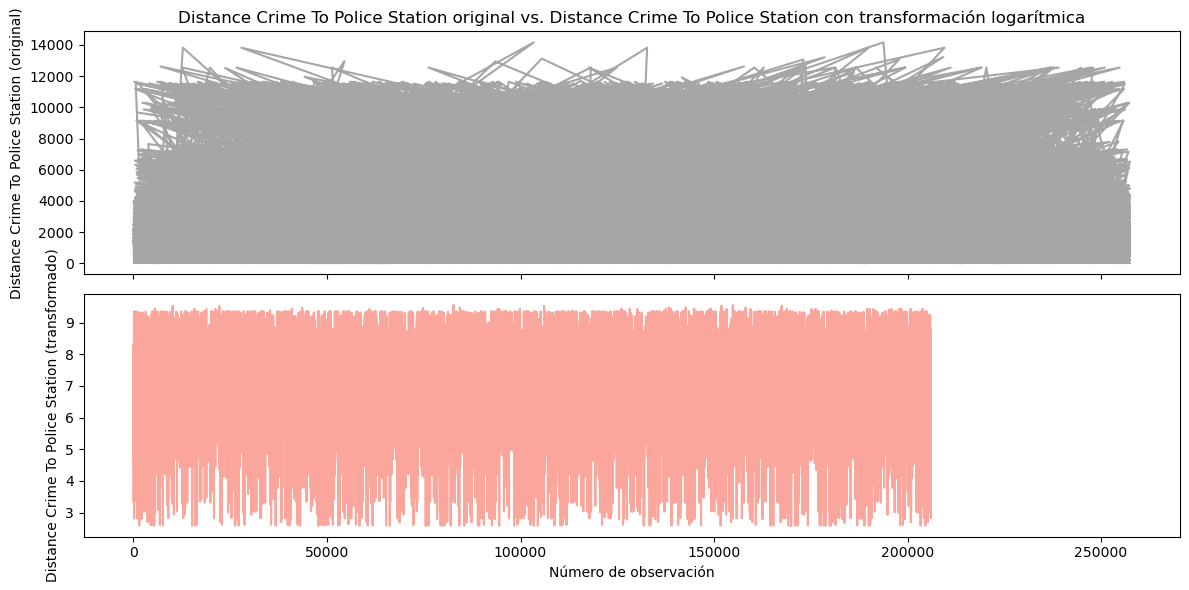

In [567]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True)

# Primer gráfico: datos originales
axes[0].plot(df.index, df['Distance Crime To Police Station'], alpha=0.7, color='gray')
axes[0].set_ylabel('Distance Crime To Police Station (original)')
axes[0].set_title('Distance Crime To Police Station original vs. Distance Crime To Police Station con transformación logarítmica')

# Segundo gráfico: datos imputados
axes[1].plot(df_transformed.index, df_transformed['Distance Crime To Police Station'], alpha=0.7, color='salmon')
axes[1].set_ylabel('Distance Crime To Police Station (transformado)')
axes[1].set_xlabel('Número de observación')

plt.tight_layout()
plt.show()

In [568]:
df_for_outliers = df_transformed[['Distance Crime To Police Station']]
Q1 = df_for_outliers.quantile(0.25)
Q3 = df_for_outliers.quantile(0.75)

IQR = Q3 - Q1
outliers_iqr = (df_for_outliers < (Q1 - 1.5 * IQR)) | (df_for_outliers > (Q3 + 1.5 * IQR))
print(f"Outliers\nDistance Crime To Police Station: <{Q1['Distance Crime To Police Station'] - 1.5 * IQR['Distance Crime To Police Station']:.02f} o >{Q3['Distance Crime To Police Station'] + 1.5 * IQR['Distance Crime To Police Station']:.02f}")

Outliers
Distance Crime To Police Station: <6.02 o >8.91


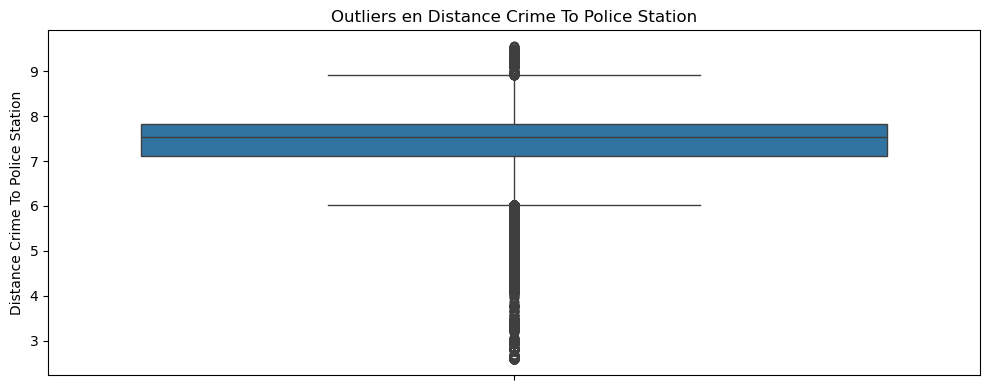

In [569]:
# Visualización de outliers con boxplots
fig, axes = plt.subplots(1, figsize=(10, 4))

# Boxplot para 'Distance Crime To Police Station'
sns.boxplot(y=df_for_outliers['Distance Crime To Police Station'], ax=axes)
axes.set_title('Outliers en Distance Crime To Police Station')

plt.tight_layout()
plt.show()

In [570]:
# Método basado en desviación estándar
mean = df_for_outliers.mean()
std = df_for_outliers.std()
# std = df_transformed.apply(lambda x: np.nanstd(x, ddof=1))

outliers_std = (df_for_outliers < (mean - 3 * std)) | (df_for_outliers > (mean + 3 * std))

print(f"Outliers\nDistance Crime To Police Station: <{mean['Distance Crime To Police Station'] - 3 * std['Distance Crime To Police Station']:.02f} o >{mean['Distance Crime To Police Station'] + 3 * std['Distance Crime To Police Station']:.02f}")

Outliers
Distance Crime To Police Station: <5.38 o >9.45


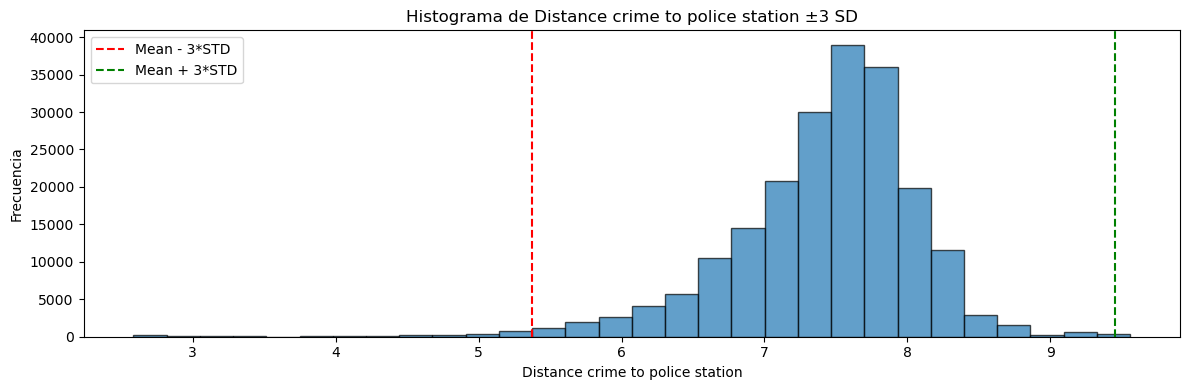

In [571]:
def plot_hist_with_std(ax, data, varname, mean, std):
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(mean[varname] - 3*std[varname], color='red', linestyle='--', label='Mean - 3*STD')
    ax.axvline(mean[varname] + 3*std[varname], color='green', linestyle='--', label='Mean + 3*STD')
    ax.set_xlabel(varname.capitalize())
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Histograma de {varname.capitalize()} ±3 SD')
    ax.legend()

fig, ax = plt.subplots(1, figsize=(12, 4))

plot_hist_with_std(ax, df_for_outliers['Distance Crime To Police Station'], 'Distance Crime To Police Station', mean, std)

plt.tight_layout()
plt.show()

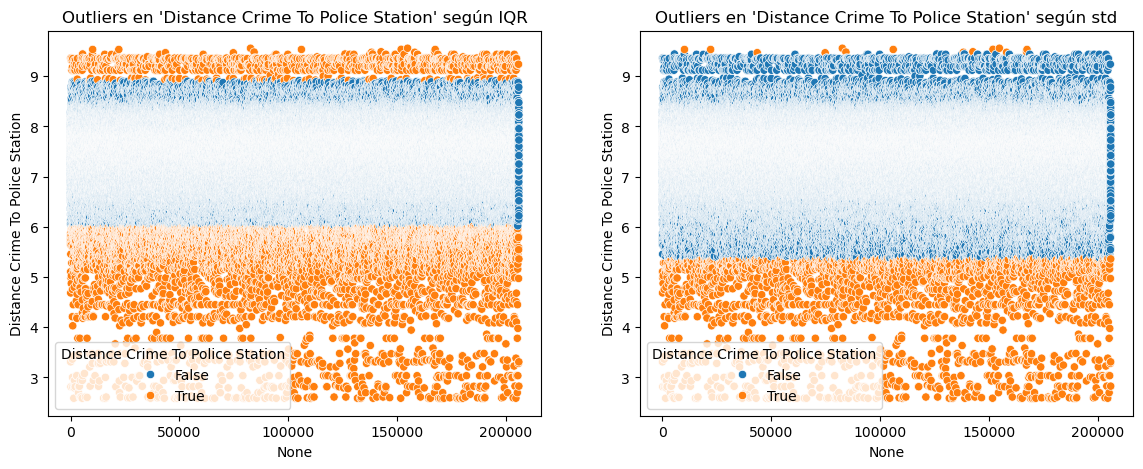

In [572]:
# Visualización con scatterplot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=df_for_outliers.index, y=df_for_outliers['Distance Crime To Police Station'], hue=outliers_iqr['Distance Crime To Police Station'], ax=ax[0])
ax[0].set_title("Outliers en 'Distance Crime To Police Station' según IQR")
sns.scatterplot(x=df_for_outliers.index, y=df_for_outliers['Distance Crime To Police Station'], hue=outliers_std['Distance Crime To Police Station'], ax=ax[1])
ax[1].set_title("Outliers en 'Distance Crime To Police Station' según std")
plt.show()

In [573]:
df_transformed[outliers_std['Distance Crime To Police Station']==True]["Arrest"].value_counts()

Arrest
False    1932
True      562
Name: count, dtype: int64

In [574]:
df_no_outliers = df_transformed[~outliers_std.any(axis=1)].copy()
df_no_outliers.describe()

,Unnamed: 0,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Distance Crime To Police Station
count,203517.000000,203517.000000,203517.000000,203517.000000,2.035170e+05,2.035170e+05,203517.000000,203517.000000,203517.000000,203517.000000
mean,129147.611816,1157.129036,23.199821,36.236098,1.165231e+06,1.887693e+06,41.847412,-87.669048,11.341593,7.449639
std,74720.767807,709.255775,13.935122,21.589396,1.619744e+04,3.154949e+04,0.086755,0.051362,7.087341,0.595763
min,0.000000,111.000000,1.000000,1.000000,1.097306e+06,1.813897e+06,41.644590,-87.768200,1.000000,5.376451
25%,64372.000000,533.000000,10.000000,22.000000,1.153909e+06,1.860542e+06,41.772676,-87.705488,5.000000,7.126770
50%,128808.000000,1034.000000,23.000000,32.000000,1.167084e+06,1.894421e+06,41.866112,-87.656973,10.000000,7.534310
75%,194208.000000,1732.000000,34.000000,53.000000,1.176640e+06,1.910445e+06,41.910022,-87.630560,17.000000,7.832032
max,258611.000000,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,31.000000,9.443448


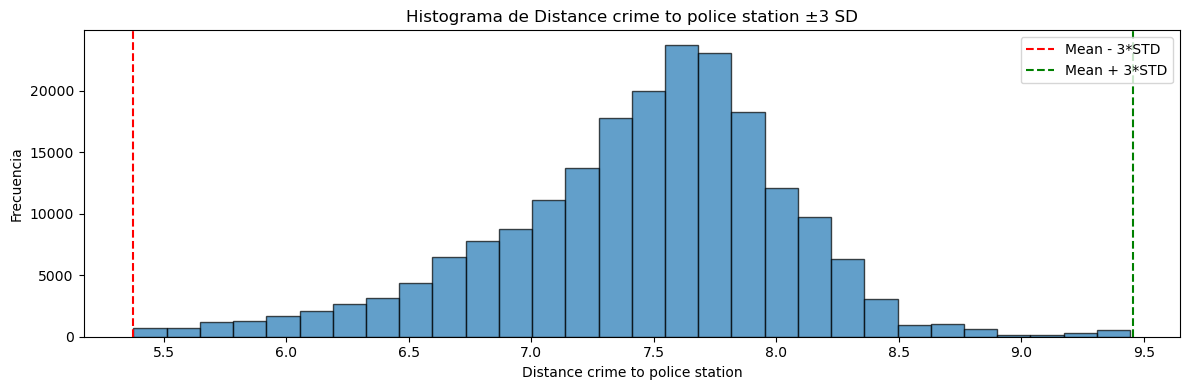

In [575]:
fig, ax = plt.subplots(1, figsize=(12, 4))

plot_hist_with_std(ax, df_no_outliers['Distance Crime To Police Station'], 'Distance Crime To Police Station', mean, std)

plt.tight_layout()
plt.show()

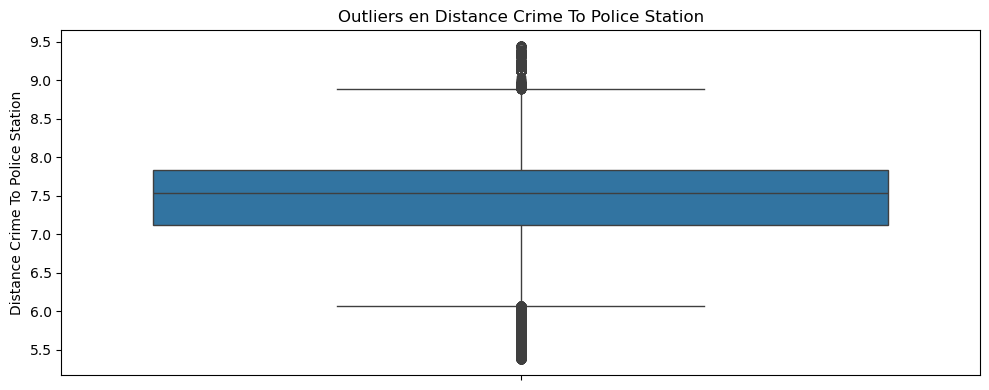

In [576]:
# Visualización de outliers con boxplots
fig, axes = plt.subplots(1, figsize=(10, 4))

# Boxplot para 'Distance Crime To Police Station'
sns.boxplot(y=df_no_outliers['Distance Crime To Police Station'], ax=axes)
axes.set_title('Outliers en Distance Crime To Police Station')

plt.tight_layout()
plt.show()

## Codificación (encoding)



In [577]:
df_no_outliers = df_no_outliers.copy()

# Convertimos columnas del dataset del crimen al tipo correcto datos de Entrenamiento
df_no_outliers['IUCR'] = df_no_outliers['IUCR'].astype('category')
df_no_outliers['Primary Type'] = df_no_outliers['Primary Type'].astype('category')
df_no_outliers['Location Description'] = df_no_outliers['Location Description'].astype('category')
df_no_outliers['FBI Code'] = df_no_outliers['FBI Code'].astype('category')
df_no_outliers['Arrest'] = df_no_outliers['Arrest'].astype('category')
df_no_outliers['Domestic'] = df_no_outliers['Domestic'].astype('category')
df_no_outliers['Crime District'] = df_no_outliers['Crime District'].astype('category')
df_no_outliers['Nearest Police Station District'] = df_no_outliers['Nearest Police Station District'].astype('category')
df_no_outliers['Nearest Police Station District Name'] = df_no_outliers['Nearest Police Station District Name'].astype('category')
df_no_outliers['Season'] = df_no_outliers['Season'].astype('category')
df_no_outliers['Day'] = df_no_outliers['Day'].astype('category')
df_no_outliers['Day Time'] = df_no_outliers['Day Time'].astype('category')

In [578]:

test_df_transformed = test_df_transformed.copy()

# Convertimos columnas del dataset del crimen al tipo correcto datos de test
test_df_transformed['IUCR'] = test_df_transformed['IUCR'].astype('category')
test_df_transformed['Primary Type'] = test_df_transformed['Primary Type'].astype('category')
test_df_transformed['Location Description'] = test_df_transformed['Location Description'].astype('category')
test_df_transformed['FBI Code'] = test_df_transformed['FBI Code'].astype('category')
test_df_transformed['Arrest'] = test_df_transformed['Arrest'].astype('category')
test_df_transformed['Domestic'] = test_df_transformed['Domestic'].astype('category')
test_df_transformed['Crime District'] = test_df_transformed['Crime District'].astype('category')
test_df_transformed['Nearest Police Station District'] = test_df_transformed['Nearest Police Station District'].astype('category')
test_df_transformed['Nearest Police Station District Name'] = test_df_transformed['Nearest Police Station District Name'].astype('category')
test_df_transformed['Season'] = test_df_transformed['Season'].astype('category')
test_df_transformed['Day'] = test_df_transformed['Day'].astype('category')
test_df_transformed['Day Time'] = test_df_transformed['Day Time'].astype('category')

In [579]:
df_no_outliers.describe(include='category')

,IUCR,Primary Type,Location Description,Arrest,Domestic,FBI Code,Crime District,Nearest Police Station District,Nearest Police Station District Name,Season,Day,Day Time
count,203517,203517,203517,203517,203517,203517,203517,203517,203517,203517,203517,203517
unique,327,31,124,2,2,26,23,23,23,4,7,4
top,0486,THEFT,STREET,False,False,06,8,3,Grand Crossing,Summer,Monday,Afternoon
freq,15982,47791,54911,175684,166236,48403,13762,18991,18991,55283,29903,63396


### Cyclic Encoding
Transforma variables cíclicas (como horas del día o meses del año) en coordenadas en un círculo.


In [580]:
# Codificación cíclica de la variable 'Day' para datos de entrenamiento
df_no_outliers["Day_num"] = df_no_outliers["Day"].map({
    "Sunday": 1, "Monday": 2, "Tuesday": 3, "Wednesday": 4, "Thursday": 5, "Friday": 6, "Saturday": 7
}).astype(int)

In [581]:
# Codificación cíclica de la variable 'Day' para datos de test
test_df_transformed["Day_num"] = test_df_transformed["Day"].map({
    "Sunday": 1, "Monday": 2, "Tuesday": 3, "Wednesday": 4, "Thursday": 5, "Friday": 6, "Saturday": 7
}).astype(int)

In [582]:
df_no_outliers["Day_sin"] = np.sin(2 * np.pi * df_no_outliers["Day_num"] / 7)

In [583]:
test_df_transformed["Day_sin"] = np.sin(2 * np.pi * test_df_transformed["Day_num"] / 7)

### One-Hot encoding datos de entrenamiento
Crea una columna binaria (0/1) para cada categoría.


In [584]:
df_no_outliers = df_no_outliers.reset_index()

In [585]:
# Inicializar el OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop="first")

# Fit + transform
encoded_array = ohe.fit_transform(df_no_outliers[["Season"]])  # Ojo! me devuelve un array de NumPy
columns=ohe.get_feature_names_out(["Season"])

# Creo un DF a partir del array
encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(["Season"]))

# Lo juntamos con el df original (en este caso no eliminamos la columna original a modo demostrativo)
df_ohe = df_no_outliers.join(encoded_df)

In [587]:
# Inicializar el OneHotEncoder
ohe_2 = OneHotEncoder(sparse_output=False, drop='first')

# Fit + transform
encoded_array = ohe_2.fit_transform(df_ohe[["Day Time"]])  # Ojo! me devuelve un array de NumPy
columns=ohe_2.get_feature_names_out(["Day Time"])

# Creo un DF a partir del array
encoded_df = pd.DataFrame(encoded_array, columns=ohe_2.get_feature_names_out(["Day Time"]))

# Lo juntamos con el df original (en este caso no eliminamos la columna original a modo demostrativo)
df_ohe_2 = df_ohe.join(encoded_df)

### One-Hot encoding datos de test
Crea una columna binaria (0/1) para cada categoría.


In [588]:
test_df_transformed = test_df_transformed.reset_index()

In [589]:
# Fit + transform
encoded_test_array = ohe.transform(test_df_transformed[["Season"]])  # Ojo! me devuelve un array de NumPy
test_columns = ohe.get_feature_names_out(["Season"])

# Creo un DF a partir del array
encoded_test_df = pd.DataFrame(encoded_test_array, columns=test_columns)

# Lo juntamos con el df original (en este caso no eliminamos la columna original a modo demostrativo)
test_df_ohe = test_df_transformed.join(encoded_test_df)

In [590]:
# Fit + transform
encoded_test_array = ohe_2.transform(test_df_ohe[["Day Time"]])  # Ojo! me devuelve un array de NumPy
test_columns=ohe_2.get_feature_names_out(["Day Time"])

# Creo un DF a partir del array
encoded_test_df = pd.DataFrame(encoded_test_array, columns=test_columns)

# Lo juntamos con el df original (en este caso no eliminamos la columna original a modo demostrativo)
test_df_ohe_2 = test_df_ohe.join(encoded_test_df)

### Label encoding

Asigna un número entero arbitrario a cada categoría (de la variable target).

In [591]:
df_label = df_ohe_2.copy()
test_df_label = test_df_ohe_2.copy()

In [592]:
df_label["Arrest_tag"] = df_label["Arrest"].astype(int)
df_label["Domestic_tag"] = df_label["Domestic"].astype(int)

test_df_label["Arrest_tag"] = test_df_label["Arrest"].astype(int)
test_df_label["Domestic_tag"] = test_df_label["Domestic"].astype(int)

In [593]:
columns_to_drop = ["Season", "Day", "Day_num", "Day Time", "index", "Arrest", "Domestic"]
df_label = df_label.drop(columns=columns_to_drop)
test_df_label = test_df_label.drop(columns=columns_to_drop)

### Frequency Encoding
Sustituye cada categoría por su frecuencia de aparición.


In [594]:
df_freq = df_label.copy()
test_df_freq = test_df_label.copy()

In [595]:
# 4. Frequency Encoding
categorical_cols = ["IUCR", "Primary Type", "Location Description", "FBI Code",
                      "Crime District", "Nearest Police Station District",
                      "Nearest Police Station District Name"]

test_df_freq[categorical_cols] = test_df_freq[categorical_cols].astype('object')

# Frequency encoding
for col in categorical_cols:
    freq_encoding = df_freq[col].value_counts(normalize=True)

    # Train
    df_freq[f"{col.replace(' ', '_')}_freq"] = df_freq[col].map(freq_encoding).astype(float)

    # Test con fillna
    test_df_freq[f"{col.replace(' ', '_')}_freq"] = test_df_freq[col].map(freq_encoding).fillna(0).astype(float)


In [596]:
columns_to_drop = ["IUCR", "Primary Type", "Location Description", "FBI Code", "Crime District", "Nearest Police Station District", "Nearest Police Station District Name"]
df_freq = df_freq.drop(columns=columns_to_drop)
test_df_freq = test_df_freq.drop(columns=columns_to_drop)

In [597]:
df_freq.describe()

,Unnamed: 0,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station,Day_sin,...,Day Time_Night,Arrest_tag,Domestic_tag,IUCR_freq,Primary_Type_freq,Location_Description_freq,FBI_Code_freq,Crime_District_freq,Nearest_Police_Station_District_freq,Nearest_Police_Station_District_Name_freq
count,203517.000000,203517.000000,203517.000000,203517.000000,2.035170e+05,2.035170e+05,203517.000000,203517.000000,203517.000000,2.035170e+05,...,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000,203517.000000
mean,129147.611816,1157.129036,23.199821,36.236098,1.165231e+06,1.887693e+06,41.847412,-87.669048,7.449639,3.950098e-03,...,0.284821,0.136760,0.183184,0.039938,0.126756,0.132513,0.117452,0.048321,0.052626,0.052626
std,74720.767807,709.255775,13.935122,21.589396,1.619744e+04,3.154949e+04,0.086755,0.051362,0.595763,7.079367e-01,...,0.451330,0.343595,0.386818,0.028798,0.076513,0.105169,0.077244,0.010938,0.022493,0.022493
min,0.000000,111.000000,1.000000,1.000000,1.097306e+06,1.813897e+06,41.644590,-87.768200,5.376451,-9.749279e-01,...,0.000000,0.000000,0.000000,0.000005,0.000015,0.000005,0.000010,0.000059,0.013164,0.013164
25%,64372.000000,533.000000,10.000000,22.000000,1.153909e+06,1.860542e+06,41.772676,-87.705488,7.126770,-7.818315e-01,...,0.000000,0.000000,0.000000,0.009753,0.065454,0.023202,0.055715,0.039667,0.035707,0.035707
50%,128808.000000,1034.000000,23.000000,32.000000,1.167084e+06,1.894421e+06,41.866112,-87.656973,7.534310,-2.449294e-16,...,0.000000,0.000000,0.000000,0.052757,0.110448,0.119931,0.084543,0.051666,0.049038,0.049038
75%,194208.000000,1732.000000,34.000000,53.000000,1.176640e+06,1.910445e+06,41.910022,-87.630560,7.832032,7.818315e-01,...,1.000000,0.000000,0.000000,0.062378,0.177882,0.269810,0.147319,0.053922,0.066820,0.066820
max,258611.000000,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,9.443448,9.749279e-01,...,1.000000,1.000000,1.000000,0.078529,0.234826,0.269810,0.237833,0.067621,0.093314,0.093314


In [598]:
df_freq.dtypes

Unnamed: 0                                     int64
Beat                                           int64
Ward                                           int64
Community Area                                 int64
X Coordinate                                 float64
Y Coordinate                                 float64
Latitude                                     float64
Longitude                                    float64
Distance Crime To Police Station             float64
Day_sin                                      float64
Season_Spring                                float64
Season_Summer                                float64
Season_Winter                                float64
Day Time_Early Morning                       float64
Day Time_Morning                             float64
Day Time_Night                               float64
Arrest_tag                                     int64
Domestic_tag                                   int64
IUCR_freq                                    f

## Salvamos en un archivo

In [599]:
df_freq.to_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv", index=False)
test_df_freq.to_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_test.csv", index=False)

## Eliminamos duplicados de la clase mayoritaria (Arrest_tag==0)

In [ ]:
df_csv = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv")

In [ ]:
df_csv.duplicated().sum()

np.int64(0)

In [ ]:
df_csv[df_csv.duplicated()]["Arrest_tag"].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
df_csv["Arrest_tag"].value_counts()

Arrest_tag
0    175684
1     27833
Name: count, dtype: int64

In [ ]:
df_csv["Arrest_tag"].value_counts(normalize=True).round(4) * 100

Arrest_tag
0    86.32
1    13.68
Name: proportion, dtype: float64

In [ ]:
# 1️⃣ identificar las filas duplicadas (ajustá subset si querés definir tus columnas)
dup_mask = df_csv.duplicated()

# 2️⃣ obtener los índices de las duplicadas con Arrest_tag == 0
idx_drop = df_csv.index[dup_mask & (df_csv["Arrest_tag"] == 0)]

# 3️⃣ eliminar esas filas
df_csv = df_csv.drop(index=idx_drop).reset_index(drop=True)


In [ ]:
dup_mask.sum()

np.int64(0)

In [ ]:
df_csv.duplicated().sum()

np.int64(0)

In [ ]:
df_csv[df_csv.duplicated()]["Arrest_tag"].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
df_csv["Arrest_tag"].value_counts()

Arrest_tag
0    175684
1     27833
Name: count, dtype: int64

In [ ]:
df_csv["Arrest_tag"].value_counts(normalize=True).round(4) * 100

Arrest_tag
0    86.32
1    13.68
Name: proportion, dtype: float64

In [ ]:
df_csv.to_csv("../datasets/chicago_crimes_and_stations_2024_encoded.csv", index=False)